In [1]:
import argparse
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss
from math import comb
import chaospy as cp

In [2]:
def gauss_legendre_rule(order):
    """
    1D Gauss-Legendre quadrature on [-1,1].
    Returns nodes x and weights w.
    """
    x, w = leggauss(order)
    return np.asarray(x, float), np.asarray(w, float)

In [3]:
# def tensor_product_rule_2d(order):
#     """
#     2D tensor-product Gauss-Legendre rule with 'order' points per dimension.
#     """
#     x, w = gauss_legendre_rule(order)
#     xx, yy = np.meshgrid(x, x, indexing='ij')
#     ww = np.outer(w, w)
#     pts = np.column_stack([xx.ravel(), yy.ravel()])
#     wts = ww.ravel()
#     return pts, wts

In [4]:
def marker_sizes(weights, smin=50, smax=550):
    """
    Scale marker area according to absolute weight magnitude.
    """
    a = np.abs(weights)
    if len(a) == 0:
        return np.array([])
    if np.allclose(a.max(), a.min()):
        return np.full_like(a, (smin + smax) / 2.0)
    return smin + (a - a.min()) / (a.max() - a.min()) * (smax - smin)

In [5]:
def save_csv(path, pts, wts):
    arr = np.column_stack([pts, wts])
    np.savetxt(path, arr, delimiter=",", header="x1,x2,weight", comments="")

In [6]:
def make_plot(gl_pts, gl_wts, sg_pts, sg_wts, gl_order, smolyak_level, out_png):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    panels = [
        (
            axes[0],
            gl_pts,
            gl_wts,
            f"Tensor-product Gauss-Legendre\n{gl_order} points/dimension ({len(gl_pts)} total)",
            "#4b5563"
        ),
        (
            axes[1],
            sg_pts,
            sg_wts,
            f"Smolyak with 1D Gauss-Legendre\nlevel {smolyak_level} ({len(sg_pts)} total)",
            "#1d4ed8"
        )
    ]

    for ax, pts, wts, title, color in panels:
        sizes = marker_sizes(wts)
        ax.scatter(
            pts[:, 0], pts[:, 1],
            s=sizes,
            c=color,
            alpha=0.78,
            edgecolors="black",
            linewidths=0.5
        )
        ax.axhline(0, color="black", lw=0.8, alpha=0.4)
        ax.axvline(0, color="black", lw=0.8, alpha=0.4)
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_aspect("equal")
        ax.set_xticks(np.linspace(-1, 1, 5))
        ax.set_yticks(np.linspace(-1, 1, 5))
        ax.grid(True, alpha=0.15)
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
        ax.set_title(title, fontsize=12)

    fig.suptitle("2D quadrature nodes; marker area proportional to |weight|", fontsize=14)
    fig.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.show()

In [35]:
gl_order = 5
smolyak_level = 3

In [36]:
dist = cp.J(
    cp.Uniform(-1, 1),
    cp.Uniform(-1, 1),
    # cp.Uniform(-1, 1),
    # cp.Uniform(-1, 1),
)

In [37]:
# gl_pts, gl_wts = tensor_product_rule_2d(gl_order)

gl_pts, gl_wts = cp.generate_quadrature(
    gl_order - 1,
    dist,
    rule="gaussian"
)
sg_pts, sg_wts = smolyak_nodes, smolyak_weights = cp.generate_quadrature(
    smolyak_level,
    dist,
    rule="gaussian",
    sparse=True
)
# sg_pts, sg_wts = smolyak_gl_2d(smolyak_level)

In [38]:
print(f"Tensor-product GL points: {gl_pts.shape[1]}")
print(f"Smolyak GL points: {sg_pts.shape[1]}")

Tensor-product GL points: 25
Smolyak GL points: 30


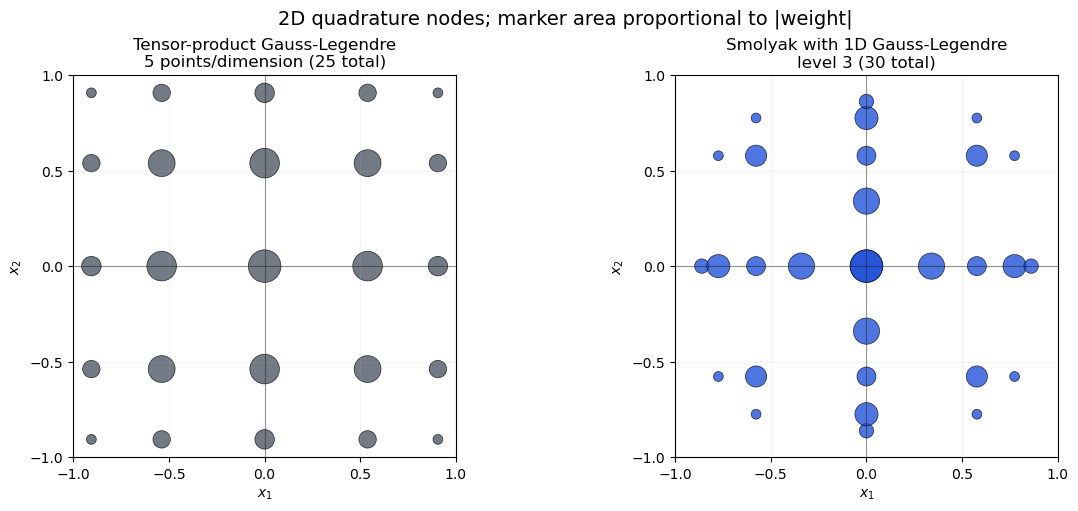

Tensor-product GL points: 25
Smolyak GL points: 30


In [39]:
make_plot(
    gl_pts.T, gl_wts,
    sg_pts.T, sg_wts,
    gl_order,
    smolyak_level,
    f"GL order ({gl_order}) vs SM level ({smolyak_level}) comparison.png"
)

print(f"Tensor-product GL points: {gl_pts.shape[1]}")
print(f"Smolyak GL points: {sg_pts.shape[1]}")
# print("Files written:")
# print(f"  {args.out_prefix}_gauss_legendre_tensor_2d.csv")
# print(f"  {args.out_prefix}_smolyak_gl_2d.csv")
# print(f"  {args.out_prefix}_comparison.png")

In [12]:
def make_plot_3d(gl_pts, gl_wts, sg_pts, sg_wts, gl_order, smolyak_level, out_png):
    fig = plt.figure(figsize=(14, 6), constrained_layout=True)

    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')

    panels = [
        (
            ax1,
            gl_pts,
            gl_wts,
            f"Tensor-product Gauss-Legendre\n{gl_order} points/dimension ({len(gl_pts)} total)",
            "#4b5563"
        ),
        (
            ax2,
            sg_pts,
            sg_wts,
            f"Smolyak with 1D Clenshaw-Curtis\nlevel {smolyak_level} ({len(sg_pts)} total)",
            "#1d4ed8"
        )
    ]

    for ax, pts, wts, title, color in panels:
        sizes = marker_sizes(wts)

        ax.scatter(
            pts[:, 0], pts[:, 1], pts[:, 2],
            s=sizes,
            c=color,
            alpha=0.75,
            edgecolors="black",
            linewidths=0.4,
            depthshade=True
        )

        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_zlim(-1, 1)

        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
        ax.set_zlabel(r"$x_3$")

        ax.set_title(title, fontsize=12)
        ax.view_init(elev=22, azim=35)

        # Make panes light and unobtrusive
        ax.xaxis.pane.set_alpha(0.08)
        ax.yaxis.pane.set_alpha(0.08)
        ax.zaxis.pane.set_alpha(0.08)

        # Light grid
        ax.grid(True, alpha=0.2)

    fig.suptitle(
        "3D quadrature nodes; marker area proportional to |weight|",
        fontsize=14
    )
    fig.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.show()

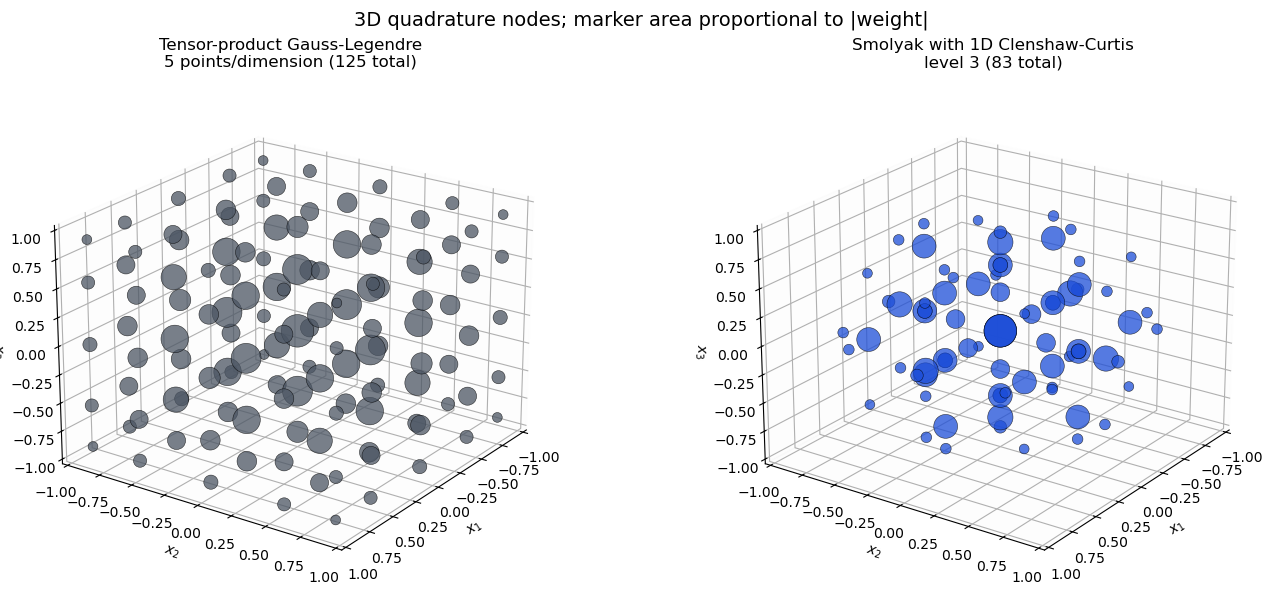

In [13]:
make_plot_3d(
    gl_pts.T, gl_wts,
    sg_pts.T, sg_wts,
    gl_order,
    smolyak_level,
    "quadrature_comparison_3d.png"
)